# MM Kinetic Analysis
___
Duncan Muir  
Last updated: 7/25/2022

In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm

## MM Functions
These are the set of functions which will help process kinetic data, I will hopefully add to the documentation over time and also make the functions themselves importable as libraries. But for now, make sure to **run these before trying to fit your data**.

In [2]:
class KineticDataException(Exception):
    pass

In [3]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [4]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [4]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 5
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
    
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [5]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    """
    Fits best initial reaction rate linearly to all kinetic series provided. Optionally plots data for visualization
    and triage.
    
    Args:
        time_arr (np.array): array of assay read times
        kinetic_data (np.array): array of kinetic signal readouts
        plot (bool): flag to turn plotting of fit slopes to scattered data on or off
        substrate_concs ([int]): optional list of substrate concentrations that must be included if plot==True
        title (str): optional title for generated plots
        fig_size ((int, int)): optional dimensions of generated plots
        triage (bool): optional flag to turn on plot "triaging" which separates each substrate's initial rate fitting  
    
    Returns:
        slopes (np.array): array of initial slopes for each sub_array in the kinetic series
        
    """
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                ax.scatter(time_arr, data)
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x, x * slope + intercept)
           
    return np.concatenate(slopes)

In [6]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [float], 
                                   e_conc: float, conc_units: str, title: str, background_rates: np.array = None):
    """
    Fits provided initial reaction rates and substrate concentrations to the Michaelis-Menten equation.
    Two replicate must be provided currently (though i will modify this in the future). If you only 
    have one replicate of data, pass it twice.
    
    Args:
        rep_1_slopes (np.array): array of initial slopes for replicate 1
        rep_2_slopes (np.array): array of initial slopes for replicate 2
        sub_concs ([float]): list of substrate concentrations that matches order of samples in each replicate
        e_conc (float): concentration of enzyme in experiment, must be in same units as sub_concs
        conc_units (str): unit name for substrate and enzyme concentration
        title (str): enzyme name/variant/description
        background_rates (np.array): optional arrays of equal dimensions to one replicate, to be subtracted prior to MM fitting
    
    Returns:
        None
        
    """
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 1000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel(f"[S] ({conc_units})")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} {conc_units}")

# Data Cleaning and Prep

In [7]:
df = pd.read_csv("../data/ecGPI_wt_1.131nM_08082022.csv", header=0)

In [8]:
df.head()

,Unnamed: 0,Time [s],temp,60 F6P µM,30 F6P µM,15 F6P µM,7.5 F6P µM,3.75 F6P µM,1.875 F6P µM,0.937 F6P µM,...,15 F6P µM.2,7.5 F6P µM.2,3.75 F6P µM.2,1.875 F6P µM.2,0.937 F6P µM.2,0.4688 F6P µM.2,0.234 F6P µM.2,0.117 F6P µM.2,0.0586 F6P µM.2,0.01465 F6P µM.2
0,1,0,22.7,6919,4241,3272,2096,1886,1039,485,...,2755,1590,1254,864,433,226,124,136,167,47
1,2,23,22.7,7083,4691,4004,2590,2563,1447,621,...,3363,2062,1904,1240,576,301,151,209,269,64
2,3,46,22.7,7326,5029,4777,3150,3292,1851,771,...,3936,2463,2472,1505,735,350,184,269,370,74
3,4,69,22.7,7510,5377,5389,3731,3853,2183,971,...,4508,3033,3068,1832,877,463,198,298,449,98
4,5,92,22.7,7646,5745,5925,4201,4523,2507,1152,...,5115,3505,3575,2165,1000,499,221,364,533,100


In [10]:
time_arr = np.array(df["Time [s]"])

In [11]:
time_arr.shape

(94,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

# Computing Background Rates

In [19]:
RFU_TO_NADPH_CONVERSION_FACTOR = 48.18

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

In [16]:
no_enz_df = df.iloc[:, 16:26]

In [17]:
no_enz_df

,30 F6P µM.1,15 F6P µM.1,7.5 F6P µM.1,3.75 F6P µM.1,1.875 F6P µM.1,0.937 F6P µM.1,0.4688 F6P µM.1,0.234 F6P µM.1,0.117 F6P µM.1,0.0586 F6P µM.1
0,3813.0,2136.0,1048.0,583.0,377.0,288.0,172.0,109.0,84.0,63.0
1,3871.0,2128.0,1087.0,574.0,409.0,277.0,162.0,111.0,80.0,51.0
2,3913.0,2115.0,1106.0,606.0,412.0,252.0,177.0,134.0,77.0,62.0
3,3845.0,2069.0,1134.0,634.0,417.0,284.0,182.0,131.0,104.0,65.0
4,3959.0,2148.0,1107.0,631.0,421.0,274.0,214.0,129.0,108.0,72.0
...,...,...,...,...,...,...,...,...,...,...
89,4220.0,2451.0,1543.0,1143.0,883.0,698.0,592.0,433.0,340.0,189.0
90,4308.0,2505.0,1541.0,1155.0,888.0,699.0,586.0,454.0,336.0,171.0
91,4247.0,2528.0,1521.0,1146.0,863.0,712.0,594.0,446.0,333.0,188.0
92,4306.0,2511.0,1512.0,1083.0,849.0,733.0,596.0,455.0,334.0,189.0


In [26]:
no_enz_arr = np.array(no_enz_df)[:-1] / RFU_TO_NADPH_CONVERSION_FACTOR
no_enz_arr.shape

(93, 10)

We need to transpose our array as our desired time count dimension is currently the first dimension.

In [27]:
no_enz_arr = no_enz_arr.transpose()
no_enz_arr.shape

(10, 93)

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

In [28]:
no_enz_rep_1_arr = no_enz_arr
no_enz_rep_2_arr = no_enz_arr

In [29]:
sub_concs = [30, 15, 7.5, 3.75, 1.875, 0.937, 0.4688, 0.234, 0.117, 0.0586]

/var/folders/hr/mq47nzpj1mvgtnm5rp1hgjsc0000gn/T/ipykernel_42127/4224871805.py:45: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_tiled * np.array(slopes).T + np.array(intercepts).T,


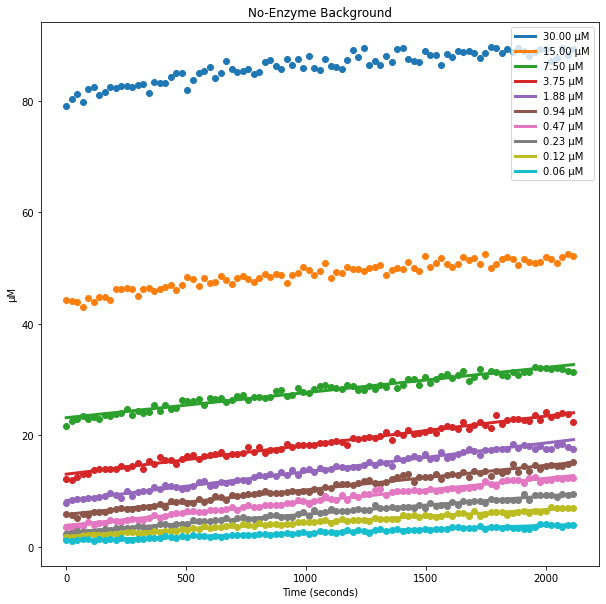

In [31]:
no_enz_rep_1_slopes = get_initial_slopes(time_arr[:-1], no_enz_rep_1_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background")

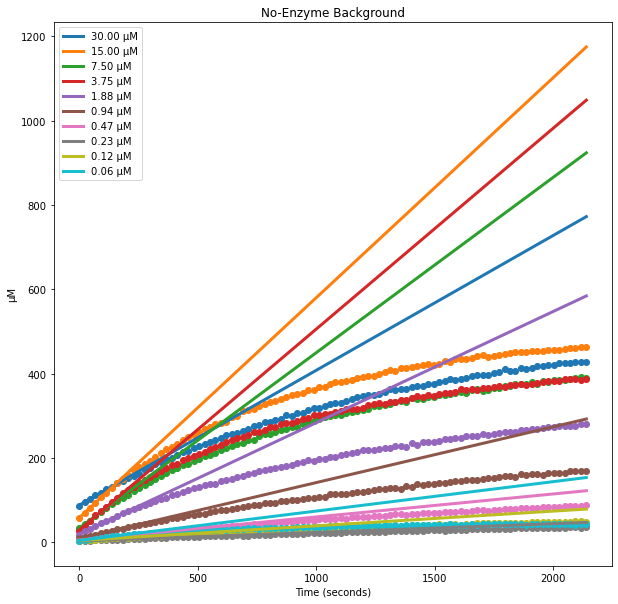

In [20]:
no_enz_rep_2_slopes = get_initial_slopes(time_arr, no_enz_rep_2_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background")

In [21]:
no_enz_rep_1_slopes

array([0.32021444, 0.52249716, 0.41639917, 0.47698546, 0.2641445 ,
       0.1324506 , 0.05461357, 0.02050611, 0.03489857, 0.06979735])

In [22]:
no_enz_rep_2_slopes

array([0.32021444, 0.52249716, 0.41639917, 0.47698546, 0.2641445 ,
       0.1324506 , 0.05461357, 0.02050611, 0.03489857, 0.06979735])

# gsADK I111L Data

In [23]:
gs_i111l_df = df.iloc[:, 1:24]
gs_i111l_arr = np.array(gs_i111l_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [24]:
gs_i111l_rep_1_arr = gs_i111l_arr[2:12]
gs_i111l_rep_2_arr = gs_i111l_arr[14:24]

In [25]:
gs_i111l_conc = 1.131 * 2e-3

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

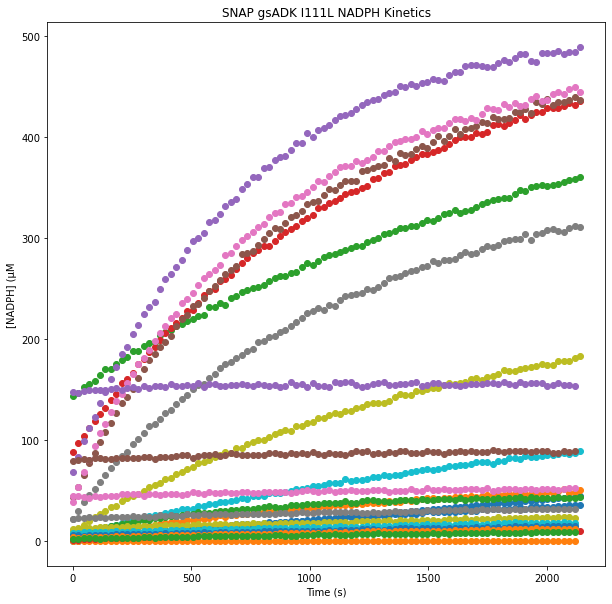

In [26]:
fig = plt.figure(figsize=(10,10))

for data in gs_i111l_arr:
    plt.scatter(time_arr, data)
plt.title("SNAP gsADK I111L NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

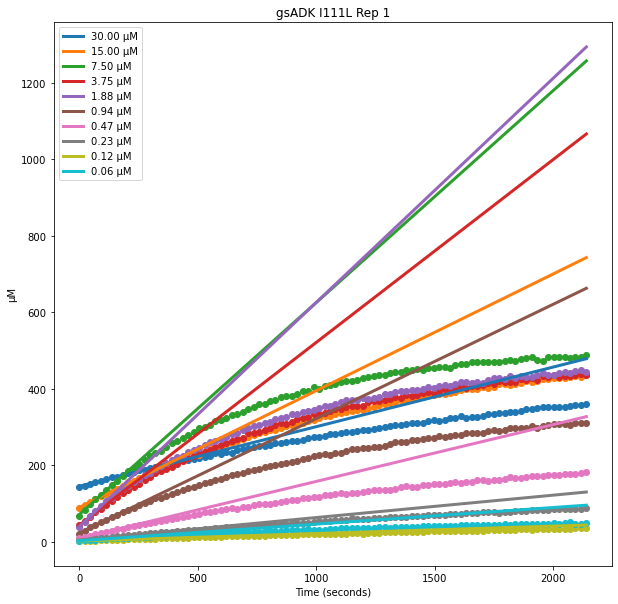

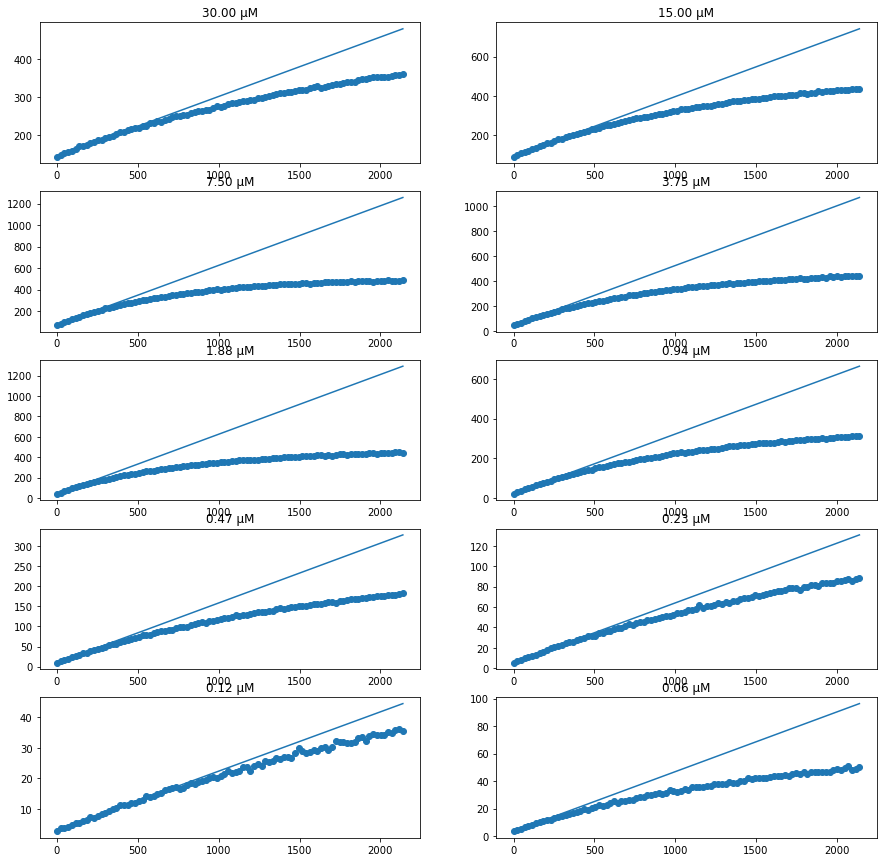

In [27]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="gsADK I111L Rep 1", triage=True)

In [28]:
gsADK_i111l_r1_slopes

array([0.15584908, 0.30514453, 0.55408708, 0.4779953 , 0.58594969,
       0.29881904, 0.14859735, 0.05854139, 0.01942903, 0.04345549])

In [29]:
gsADK_i111l_r2_slopes = get_initial_slopes(time_arr, gs_i111l_rep_2_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="gsADK I111L Rep 2")

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

In [ ]:
gsADK_i111l_r2_slopes

In [ ]:
fit_and_plot_micheaelis_menten(gsADK_i111l_r1_slopes,
                               gsADK_i111l_r2_slopes,
                               sub_concs, 
                               gs_i111l_conc,
                               "µM",
                               "SNAP gsADK I111L",
                               np.mean([no_enz_rep_1_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])